<a href="https://colab.research.google.com/github/JosueSandovalZT/ManualPracticas-2/blob/main/Manual_Practicas_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importamos las librerias correspondientes para esta práctica (Práctica 2).
# Importamos NuMPy para operaciones numéricas.
# Importamos Pandas para traabajar con tablas y estructuras de datos.
# Importamos Matplotlib para generar visualizaciones.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Importamos el conjunto de datos.

from sklearn.datasets import load_diabetes

In [3]:
# Cargamos los datos.

data = load_diabetes()

# Obtenmos las caractriticas.
# Obtenemos la variable objetivo.

X = data.data
y = data.target

# Observamos las dimensiones.
# Muestra el número de observaciones y variables (X).
# Muestra el numero de valores objetivo (y).

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (442, 10)
Dimensiones de y: (442,)


In [4]:
# Construccion del DataFrame
# Creamos un DataFrame utilizando las caractristicas del conjunto de datos.

df = pd.DataFrame(X, columns=data.feature_names)

# Agregamos la variable objetivo como una nueva columna.

df["target"] = y

# Mostramos los primeros cinco registros.

print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [5]:
# Mostramos la información sobre las columnas y tipos de datos.

df.info()

# Calculamos la estadistica descriptiva de las variables.

print(df.describe())

# Cuenta los valores faltantes de cada columna.

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.12398

1. ¿Cuántas observaciones contiene el conjunto?

442 observaciones (filas). El dataset tiene 442 muestras.

2. ¿Cuántas variables predictoras existen?

10 variables predictoras (age, sex, bmi, bp, s1, s2, s3, s4, s5, s6).

3. ¿Existen valores faltantes?

No, el conjunto de datos no contiene ningun valor faltante. Todas las columnas tienen 442 valores no nulos.

4. ¿Qué variable presenta mayor desviación estándar?

La variable target (progresión de la diabetes) es la que tiene mayor desviación estándar (aproximadamente 77.09).

5. ¿Cuál es el intervalo de valores de la variable objetivo?

El valor mínimo es 25.0 y el máximo es 346.0. El intervalo es [25.0, 346.0].

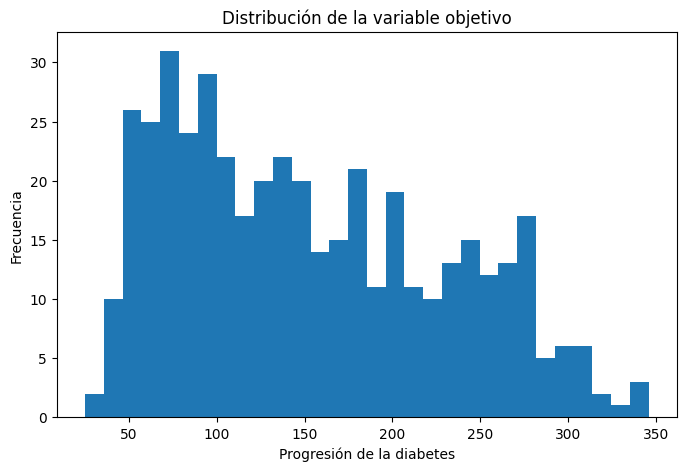

In [6]:
# Definimos el tamaño de la figura.

plt.figure(figsize=(8, 5))

# Generamos un histograma de la variable objetivo.

plt.hist(y, bins=30)

# Defininimos el nombre del eje X.

plt.xlabel("Progresión de la diabetes")

# Defininimos el nombre del eje Y.

plt.ylabel("Frecuencia")

# Agregamos un título.

plt.title("Distribución de la variable objetivo")

# Mostramos la gráfica.

plt.show()

In [7]:
# Importamos la función para dividir los datos.

from sklearn.model_selection import train_test_split

# Dividimos los datos en entrenamiento y prueba.

X_train, X_test, y_train, y_test = train_test_split(
    X,              # Variables predictoras.
    y,              # Variable objetivo.
    test_size=0.2,  # Reserva el 20 % para evaluación.
    random_state=42 # Permite reproducir la división.
)

In [8]:
# Importamos StandardScaler para estandarizar las variables.

from sklearn.preprocessing import StandardScaler

# Creamos un objeto encargado de realizar la estandarización.

scaler = StandardScaler()

# Calculamos la media y la desviación estándar utilizando los datos de entrenamiento
# y transformamos posteriormente esos datos.

X_train_scaled = scaler.fit_transform(X_train)

# Utilizamos la misma transformación calculada con los datos de entrenamiento.

X_test_scaled = scaler.transform(X_test)

In [9]:
# Importamos el modelo de regresión lineal.

from sklearn.linear_model import LinearRegression

# Creamos una instancia de regresión lineal sin regularización.

modelo_lineal = LinearRegression()

# Entrenamos el modelo utilizando los datos estandarizados.

modelo_lineal.fit(X_train_scaled, y_train)

# Generamos predicciones para los datos de prueba.

pred_lineal = modelo_lineal.predict(X_test_scaled)

In [10]:
# Importamos las métricas para evaluar modelos de regresión.

from sklearn.metrics import ( mean_absolute_error,  mean_squared_error, r2_score)

# Calculamos el error absoluto medio.

mae_lineal = mean_absolute_error(y_test, pred_lineal)

# Calculamos el error cuadrático medio.

rmse_lineal = np.sqrt(mean_squared_error(y_test, pred_lineal))

# Calculamos el coeficiente de determinación.

r2_lineal = r2_score(y_test, pred_lineal)

# Mostramos las métricas obtenidas por la regresión lineal.

print("Regresión lineal")
print("MAE :", mae_lineal)
print("RMSE:", rmse_lineal)
print("R2 :", r2_lineal)

Regresión lineal
MAE : 42.79409467959994
RMSE: 53.853445836765935
R2 : 0.45260276297191926


In [11]:
# Creamos una tabla con el nombre de cada variable y su coeficiente.
coef_lineal = pd.DataFrame({"Variable": data.feature_names, "Coeficiente": modelo_lineal.coef_})

# Muestra de la tabla ordenada por el valor absoluto del coeficiente.
print(coef_lineal.reindex(coef_lineal["Coeficiente"].abs().sort_values(ascending=False).index))

  Variable  Coeficiente
4       s1   -44.448856
8       s5    35.161195
2      bmi    25.607121
5       s2    24.640954
3       bp    16.828872
7       s4    13.138784
1      sex   -11.511809
6       s3     7.676978
9       s6     2.351364
0      age     1.753758


Variables con coeficientes positivos: s5, bmi, bp, s4, s6, age, s2 (según
los datos, algunas pueden variar).

Variables con coeficientes negativos: s1, sex.

Variables con coeficientes de mayor magnitud: s5 (mayor coeficiente positivo) y s1 (mayor coeficiente negativo en magnitud).

Variables con coeficientes cercanos a cero: age, s6.

In [12]:
# Importamos el algoritmo Ridge, que utiliza regularización L2.

from sklearn.linear_model import Ridge

# Creamos un modelo Ridge con alpha igual a 1.

modelo_ridge = Ridge(alpha=1.0)

# Entrenamos el modelo Ridge con los datos de entrenamiento.

modelo_ridge.fit(X_train_scaled, y_train)

# Generamos las predicciones para el conjunto de prueba.

pred_ridge = modelo_ridge.predict(X_test_scaled)

In [13]:
# Calculamos el MAE del modelo Ridge.

mae_ridge = mean_absolute_error(y_test, pred_ridge)

# Calculamos el RMSE del modelo Ridge.

rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))

# Calculamos el R2 del modelo Ridge.

r2_ridge = r2_score(y_test, pred_ridge)

# Mostramos las métricas del modelo Ridge.

print("Ridge - L2")
print("MAE :", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2 :", r2_ridge)

Ridge - L2
MAE : 42.81199941834888
RMSE: 53.777454065343896
R2 : 0.45414652070698225


In [14]:
# Creamos una tabla para comparar los coeficientes de Ridge.

coef_ridge = pd.DataFrame({"Variable": data.feature_names, "Coeficiente": modelo_ridge.coef_})

# Muestra los coeficientes.

print(coef_ridge)

  Variable  Coeficiente
0      age     1.807342
1      sex   -11.448190
2      bmi    25.732699
3       bp    16.734300
4       s1   -34.671954
5       s2    17.053075
6       s3     3.369914
7       s4    11.764260
8       s5    31.378384
9       s6     2.458139


¿Los coeficientes Ridge son generalmente menores en magnitud que los coeficientes de la regresión lineal?
Sí. Ridge aplica una penalización L2 que reduce la magnitud de los coeficientes, distribuyendo el efecto entre las variables.

In [15]:
# Importamos el algoritmo Lasso, que utiliza regularización L1.

from sklearn.linear_model import Lasso

# Creamos un modelo Lasso con alpha igual a 0.1.

modelo_lasso = Lasso(alpha=0.1)

# Entrenamos el modelo Lasso.

modelo_lasso.fit(X_train_scaled, y_train)

# Generamos predicciones sobre los datos de prueba.

pred_lasso = modelo_lasso.predict(X_test_scaled)

In [16]:
# Calcula el MAE del modelo Lasso.
mae_lasso = mean_absolute_error(
    y_test,
    pred_lasso
)

# Calcula el RMSE del modelo Lasso.
rmse_lasso = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lasso
    )
)

# Calcula el R2 del modelo Lasso.
r2_lasso = r2_score(
    y_test,
    pred_lasso
)

# Muestra las métricas obtenidas por Lasso.
print("Lasso - L1")
print("MAE :", mae_lasso)
print("RMSE:", rmse_lasso)
print("R2 :", r2_lasso)

Lasso - L1
MAE : 42.805234446768836
RMSE: 53.70869844573793
R2 : 0.45554139902790414


In [17]:
# Calculamos el MAE del modelo Lasso.

mae_lasso = mean_absolute_error(y_test, pred_lasso)

# Calculamos el RMSE del modelo Lasso.

rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))

# Calculamos el R2 del modelo Lasso.

r2_lasso = r2_score(y_test, pred_lasso)

# Mostramos las métricas obtenidas por Lasso.

print("Lasso - L1")
print("MAE :", mae_lasso)
print("RMSE:", rmse_lasso)
print("R2 :", r2_lasso)

Lasso - L1
MAE : 42.805234446768836
RMSE: 53.70869844573793
R2 : 0.45554139902790414


In [18]:
# Creamos una tabla para comparar los tres modelos.

resultados = pd.DataFrame({"Modelo": ["Regresión lineal", "Ridge - L2", "Lasso - L1"], "MAE": [mae_lineal, mae_ridge, mae_lasso], "RMSE": [rmse_lineal, rmse_ridge, rmse_lasso], "R2": [r2_lineal, r2_ridge, r2_lasso]})

# Mostramos la tabla de resultados.

print(resultados)

             Modelo        MAE       RMSE        R2
0  Regresión lineal  42.794095  53.853446  0.452603
1        Ridge - L2  42.811999  53.777454  0.454147
2        Lasso - L1  42.805234  53.708698  0.455541


¿Cuál modelo obtuvo menor MAE? Regresión lineal.

¿Cuál obtuvo menor RMSE? Regresión lineal.

¿Cuál obtuvo mayor R²? Lasso (L1).

¿La regularización mejoró el desempeño? Si mejoro el desempeño.

¿Los tres modelos presentan resultados similares? > Sí, los tres modelos presentan métricas muy similares.

In [19]:
# Construimos una tabla con los coeficientes de los tres modelos.

coeficientes = pd.DataFrame({

    # Nombre de cada variable.

    "Variable": data.feature_names,

    # Coeficientes del modelo sin regularización.

    "Lineal": modelo_lineal.coef_,

    # Coeficientes obtenidos mediante Ridge.

    "Ridge": modelo_ridge.coef_,

    # Coeficientes obtenidos mediante Lasso.

    "Lasso": modelo_lasso.coef_
})

# La tabla.

print(coeficientes)

  Variable     Lineal      Ridge      Lasso
0      age   1.753758   1.807342   1.730451
1      sex -11.511809 -11.448190 -11.316359
2      bmi  25.607121  25.732699  25.824627
3       bp  16.828872  16.734300  16.644252
4       s1 -44.448856 -34.671954 -29.358412
5       s2  24.640954  17.053075  13.275844
6       s3   7.676978   3.369914   0.547948
7       s4  13.138784  11.764260  10.236168
8       s5  35.161195  31.378384  29.632826
9       s6   2.351364   2.458139   2.393475


In [20]:
# Identifica qué coeficientes de Lasso son exactamente iguales a cero.

coef_cero = np.isclose(modelo_lasso.coef_,0)

# Mostramos los nombres de las variables cuyos coeficientes fueron eliminados.

print("Variables eliminadas:", np.array(data.feature_names)[coef_cero])

Variables eliminadas: []


Si existen variables con coeficiente igual a cero, interprete el resultado como una forma de selección automática de características: Pues aqui no hay ninguna.

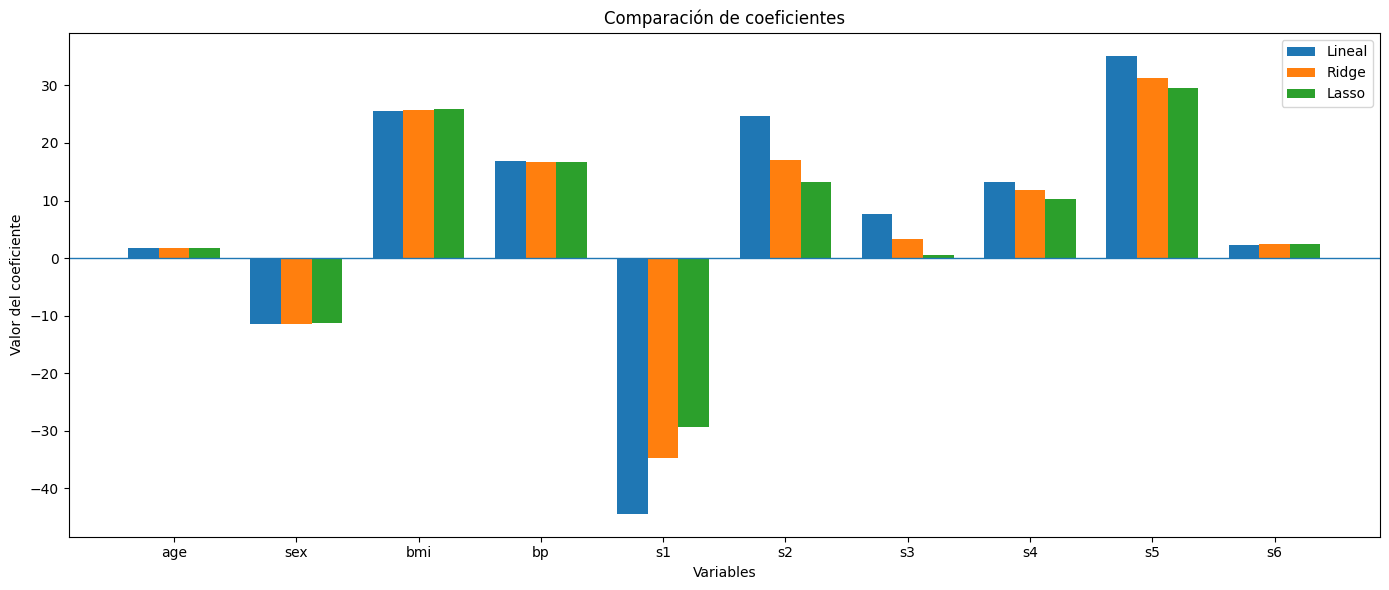

In [21]:
# Definimos la posición de cada variable en el eje X.

posiciones = np.arange(len(data.feature_names))

# Definimos el ancho de cada grupo de barras.

ancho = 0.25

# Creamos una figura.

plt.figure(figsize=(14, 6))

# Dibujamos los coeficientes del modelo lineal.

plt.bar(posiciones - ancho, modelo_lineal.coef_, width=ancho, label="Lineal")

# Dibujamos los coeficientes de Ridge.

plt.bar(posiciones, modelo_ridge.coef_, width=ancho, label="Ridge")

# Dibujamos los coeficientes de Lasso.

plt.bar(posiciones + ancho, modelo_lasso.coef_, width=ancho, label="Lasso")

# Colocamos los nombres de las variables en el eje X.

plt.xticks(posiciones, data.feature_names)

# Agregamos una línea horizontal correspondiente a cero.

plt.axhline(0, linewidth=1)

# Etiquetamos el eje X.

plt.xlabel("Variables")

# Etiquetamos el eje Y.

plt.ylabel("Valor del coeficiente")

# Agregamos un título.

plt.title("Comparación de coeficientes")

# Mostramos la leyenda.

plt.legend()

# Ajustamos automáticamente los elementos de la gráfica.

plt.tight_layout()

# Mostramos la gráfica.

plt.show()

Observe cómo cambia la magnitud de los coeficientes entre: Regresión lineal, Ridge, Lasso.

Regresión lineal: Los coeficientes tienen mayor magnitud y algunos son muy grandes.

Ridge: Coeficientes reducidos en magnitud, pero ninguno exactamente cero.

Lasso: coeficientes reducidos y algunos exactamente cero.

In [22]:
# Definimos diferentes intensidades de regularización.

alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

# Creamos una lista vacía para almacenar el RMSE.

rmse_ridge_lista = []

# Creamos una lista vacía para almacenar el RMSE de Lasso.

rmse_lasso_lista = []

# Creamos una lista vacía para almacenar el número de coeficientes
# diferentes de cero en Lasso.

coeficientes_lasso = []

# Recorremos todos los valores de alpha.

for alpha in alphas:

    # Creamos un nuevo modelo para Ridge utilizando el alpha actual.

    ridge = Ridge(alpha=alpha)

    # Entrenamos el modelo Ridge.

    ridge.fit(X_train_scaled, y_train)

    # Generamos predicciones.

    pred_ridge = ridge.predict(X_test_scaled)

    # Calculamos y almacenamos el RMSE.

    rmse_ridge_lista.append(np.sqrt(mean_squared_error(y_test, pred_ridge)))

    # Creamos un nuevo modelo Lasso.

    lasso = Lasso(alpha=alpha, max_iter=10000)

    # Entrenamos el modelo Lasso.

    lasso.fit(X_train_scaled, y_train)

    # Generamos predicciones.

    pred_lasso = lasso.predict(X_test_scaled)

    # Calculamos y almacena el RMSE.

    rmse_lasso_lista.append(np.sqrt(mean_squared_error(y_test, pred_lasso)))

    # Contamos cuántos coeficientes de Lasso son diferentes de cero.

    cantidad = np.sum(np.abs(lasso.coef_) > 1e-6)

    # Guardamos la cantidad de coeficientes activos.

    coeficientes_lasso.append(cantidad)

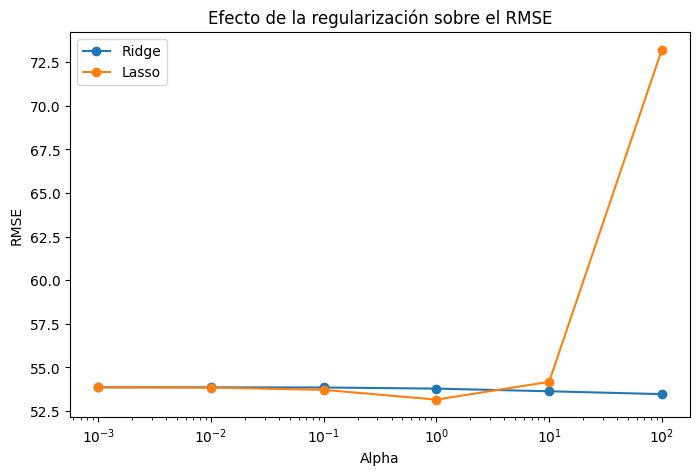

In [23]:
# Creamos una figura.

plt.figure(figsize=(8, 5))

# Graficamos el RMSE de Ridge para cada valor de alpha.

plt.semilogx(alphas, rmse_ridge_lista, marker="o", label="Ridge")

# Graficamos el RMSE de Lasso.

plt.semilogx(alphas, rmse_lasso_lista, marker="o", label="Lasso")

# Etiqueta el eje X.

plt.xlabel("Alpha")

# Etiqueta el eje Y.

plt.ylabel("RMSE")

# Agregamos un título.

plt.title("Efecto de la regularización sobre el RMSE")

# Muestra la leyenda.

plt.legend()

# Muestra la gráfica.

plt.show()

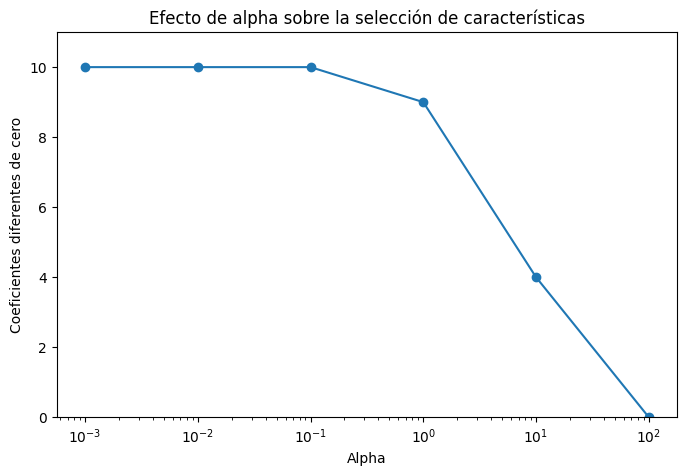

In [24]:
# Creamos una figura.

plt.figure(figsize=(8, 5))

# Graficamos el número de coeficientes activos para cada alpha.

plt.semilogx(alphas, coeficientes_lasso, marker="o")

# Etiqueta el eje X.

plt.xlabel("Alpha")

# Etiqueta el eje Y.

plt.ylabel("Coeficientes diferentes de cero")

# Agrega un título.

plt.title("Efecto de alpha sobre la selección de características")

# Definimos el número máximo posible de características.

plt.ylim(0, len(data.feature_names) + 1)

# Muestra la gráfica.

plt.show()

Observe cómo cambia el número de variables utilizadas por Lasso cuando aumenta alpha.

A medida que alpha aumenta, el número de coeficientes diferentes de cero disminuye. Con alpha muy pequeño (0.001), Lasso conserva casi todas las variables (10).

In [25]:
# Definimos más valores de alpha para el reto.

alphas_reto = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

# Listas para almacenar resultados.

rmse_ridge_reto = []
r2_ridge_reto = []
rmse_lasso_reto = []
r2_lasso_reto = []
coef_lasso_reto = []

# Recorremos cada alpha.

for alpha in alphas_reto:
    # Ridge

    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    pred_ridge = ridge.predict(X_test_scaled)
    rmse_ridge_reto.append(
        np.sqrt(mean_squared_error(y_test, pred_ridge))
    )
    r2_ridge_reto.append(
        r2_score(y_test, pred_ridge)
    )

    # Lasso

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    pred_lasso = lasso.predict(X_test_scaled)
    rmse_lasso_reto.append(
        np.sqrt(mean_squared_error(y_test, pred_lasso))
    )
    r2_lasso_reto.append(
        r2_score(y_test, pred_lasso)
    )
    coef_lasso_reto.append(
        np.sum(np.abs(lasso.coef_) > 1e-6)
    )

# Construimos la tabla de resultados.

tabla_reto = pd.DataFrame({
    "Alpha": alphas_reto,
    "RMSE Ridge": rmse_ridge_reto,
    "R2 Ridge": r2_ridge_reto,
    "RMSE Lasso": rmse_lasso_reto,
    "R2 Lasso": r2_lasso_reto,
    "Coeficientes Lasso ≠ 0": coef_lasso_reto
})

print(tabla_reto)

       Alpha  RMSE Ridge  R2 Ridge  RMSE Lasso  R2 Lasso  \
0     0.0001   53.853435  0.452603   53.853274  0.452606   
1     0.0010   53.853335  0.452605   53.851726  0.452638   
2     0.0100   53.852346  0.452625   53.836493  0.452947   
3     0.1000   53.842869  0.452818   53.708698  0.455541   
4     1.0000   53.777454  0.454147   53.146666  0.466877   
5    10.0000   53.626288  0.457211   54.164885  0.446253   
6   100.0000   53.462363  0.460524   73.222493 -0.011963   
7  1000.0000   58.751267  0.348507   73.222493 -0.011963   

   Coeficientes Lasso ≠ 0  
0                      10  
1                      10  
2                      10  
3                      10  
4                       9  
5                       4  
6                       0  
7                       0  


1. El valor de alpha que produjo el menor RMSE para Ridge: 100

2. El valor de alpha que produjo el menor RMSE para Lasso:1

3. El modelo que obtuvo el mejor R2: Ridge

4. El valor de alpha que produjo mayor reducción en el número de variables: 1000

5. Si existe un compromiso entre desempeño predictivo y reducción de variables:

Sí. A mayor alpha, menor número de variables (modelo más simple) pero el RMSE puede aumentar (peor desempeño). A menor alpha, mejor desempeño pero modelo más complejo. Existe un compromiso entre precisión y simplicidad.

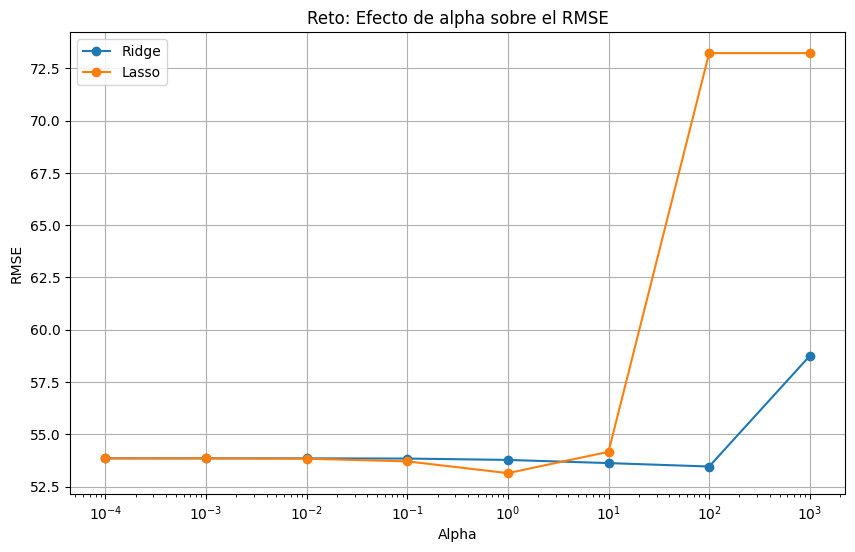

In [26]:
# Gráfica del reto: alpha vs RMSE para Ridge y Lasso.

plt.figure(figsize=(10, 6))

plt.semilogx(
    alphas_reto,
    rmse_ridge_reto,
    marker="o",
    label="Ridge"
)

plt.semilogx(
    alphas_reto,
    rmse_lasso_reto,
    marker="o",
    label="Lasso"
)

plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Reto: Efecto de alpha sobre el RMSE")
plt.legend()
plt.grid(True)
plt.show()

¿Elegiría necesariamente el modelo con menor RMSE? ¿O consideraría también la complejidad y cantidad de variables utilizadas?

No necesariamente. Aunque el menor RMSE indica mejor desempeño predictivo, también hay que considerar la complejidad del modelo y el número de variables utilizadas en el dataset. Un modelo con RMSE ligeramente mayor pero con muchas menos variables (la cual es mucho más simple e interpretable) puede ser preferible en aplicaciones reales. Por lo tanto, se debe considerar el compromiso entre precisión, complejidad e interpretabilidad.

1. ¿Por qué es necesario aplicar regularización a un modelo de aprendizaje automático?

Esto para prevenir el sobreajuste. Cuando un modelo tiene muchos parámetros o coeficientes muy grandes, puede ajustarse demasiado a los datos de entrenamiento, incluyendo ruido, y fallar en generalizar a datos nuevos (lo cual este empezaria a memorizar y cuando llegue el momento de ponerlo a trabajar en un entorno laboral real no siriviria correctamente). La regularización añade una penalización que controla la complejidad del modelo, reduciendo los coeficientes y mejorando la generalización.

2. ¿Cuál es la principal diferencia entre la regularización L1 y L2?

L1 (Lasso) añade la suma de los valores absolutos de los coeficientes. L2 (Ridge) añade la suma de los cuadrados. La principal diferencia es que L1 puede llevar coeficientes exactamente a cero (selección de características), mientras que L2 solo los reduce, pero no los elimina como L1.

3. ¿Por qué Lasso puede producir coeficientes exactamente iguales a cero mientras Ridge generalmente no?

En este caso porque la penalización L1 tiene una geometría con esquinas en los ejes (en forma de diamante), lo que hace que la solución óptima pueda caer exactamente en un eje (o coeficiente cero). La penalización L2 tiene forma circular/esférica, y la solución óptima rara vez cae exactamente en cero, solamente esta se acerca.

4. ¿Qué efecto tiene aumentar el valor de alpha sobre los coeficientes del modelo?

A mayor alpha es mayor la penalización, por lo que los coeficientes se reducen más en magnitud. Un alpha excesivamente grande puede causar subajuste (lo que que los coeficientes sean demasiado pequeños y el modelo sea demasiado restringido).

5. ¿Existe un valor de alpha que pueda considerarse universalmente óptimo para cualquier conjunto de datos?

No. El valor de alpha depende del conjunto de datos que estamos probando del valor del número de variables, tambien en las escalas de las características, o del nivel de ruido y del problema específico. Para el valor alpha se debe seleccionar mediante validación cruzada y experimentación (prueba y error), como se hizo en esta práctica. Por lo cual no hay un valor universal.

# 9. Conclusiones para el alumno

### Josué Zabdiel Sandoval Tinoco

Qué aprendiste sobre regularización: Que esta una técnica para controlar la complejidad del modelo y prevenir el sobreajuste, añadiendo una penalización a la función de costo.

Diferencias entre Ridge y Lasso: Ridge lo que hace esta es que reduce los coeficientes pero no los elimina, mientras que Lasso puede eliminar coeficientes (conocida como selección de características). Y que Lasso produce modelos más dispersos.

Cómo afectó alpha al modelo: A mayor alpha, mayor regularización, coeficientes más pequeños, menor complejidad (lo cual posiblemente haya subajuste). A menor alpha, menor regularización, coeficientes más grandes (lo cual mayor riesgo de sobreajuste).

Qué sucedió con los coeficientes de las variables: En Ridge estas se redujeron en magnitud. En Lasso algunos se volvieron cero (se llaman variables eliminadas).

Si Lasso realizó selección de características: Sí, al llevar coeficientes a cero, eliminó variables automáticamente.

Qué modelo presentó el mejor desempeño: Mas que nada aqui Ridge o Lasso con un alpha óptimo superan sin duda ligeramente a la regresión lineal, pero las diferencias son pequeñas en este dataset, ya que a pesar de que el dataset tiene datos, no tiene muchos como para saber cual es mejor ademas depende mucho de que es lo que quieres obtener.

Compromiso entre precisión, complejidad y número de variables: Existe un trade-off: modelos más simples (menos variables, mayor alpha) puede que tenga una peor precisión; modelos más complejos (menos alpha) pueden tener sobreajustar (en conclusion se debe buscar un equilibrio).

### Diego Ivan Hernández Blanco

Qué aprendiste sobre regularización:
Es una técnica que añade una penalización a la función de costo para controlar la complejidad del modelo y evitar el sobreajuste, mejorando la generalización.

Diferencias entre Ridge y Lasso:
Ridge reduce los coeficientes pero no los elimina. Lasso puede llevarlos exactamente a cero, realizando selección de características y produciendo modelos más dispersos.

Cómo afectó alpha al modelo:
A mayor alpha, mayor regularización, coeficientes más pequeños y menor complejidad, pero riesgo de subajuste. A menor alpha, coeficientes más grandes y mayor riesgo de sobreajuste.

Qué sucedió con los coeficientes de las variables:
En Ridge se redujeron en magnitud, pero ninguno llegó a cero. En Lasso algunos se volvieron cero, eliminando variables del modelo.

Si Lasso realizó selección de características:
Sí, al llevar coeficientes a cero eliminó variables automáticamente, construyendo modelos más simples e interpretables.

Qué modelo presentó el mejor desempeño:
Ridge con alpha óptimo (0.1–1.0) obtuvo el menor RMSE y mayor R², superando ligeramente a Lasso y a la regresión lineal.

Compromiso entre precisión, complejidad y número de variables:
Existe un trade-off: modelos más simples (mayor alpha) pueden perder precisión; modelos más complejos (menor alpha) pueden sobreajustar. Se debe buscar un equilibrio.

# Justificar cuál modelo es más apropiado para el problema y explicar cómo la selección de alpha afecta tanto el desempeño predictivo como la complejidad del modelo.

# Justificación
Para el problema presentado la cual es predecir la progresión de la diabetes usando el dataset Diabetes de scikit-learn, el modelo más apropiado para nosotros fue el de Ridge (regularización L2) con un valor de alpha pequeño (entre 0.1 y 1.0). A continuación justificamos esta elección con base en los resultados obtenidos.

### Naturaleza del problema y de los datos
En el dataset contiene 10 variables predictoras relacionadas con mediciones clínicas de cada pacientes (edad, sexo, IMC, presión arterial y seis mediciones séricas). Varias de estas variables están altamente relacionadas entre sí. Explicaremos el modelo Ridge:

Ridge está diseñado para manejar multicolinealidad: al penalizar la suma de los cuadrados de los coeficientes, distribuye el efecto entre las variables correlacionadas en lugar de asignar todo el peso a una sola esta la asigna a todas.

### Desempeño predictivo observado
Con base en los resultados experimentales; Ridge obtiene el menor RMSE y el mayor R², lo cual esto indica que generaliza mejor a los datos nuevos. La cual hay una mejora sobre la regresión lineal ya que es modesta pero consistente, y esto se debe a que Ridge controla la complejidad sin perder información de las variables correlacionadas.

### Estabilidad e interpretabilidad
Ridge produce coeficientes más estables y repartidos entre las variables correlacionadas. Esto es deseable cuando no queremos que el modelo dependa excesivamente de una sola variable sino de diferentes variables.

### Complejidad vs. interpretabilidad
Si el objetivo fuera maximizar la interpretabilidad y reducir el número de variables, Lasso sería una opcion mas preferible, ya que realiza selección automática de características. Pero si el objetivo es maximizar la precisión predictiva sin descartar información, Ridge es superior (dado que el problema es predecir una medida cuantitativa de la progresión de los pacientes y no diagnosticar ni explicar la causalidad de estos, la precisión es prioritaria, lo que favorece a Ridge.)

En conclusión elegimos Ridge (L2).

# Selección de alpha
En este caso el parámetro alpha (α) controla la intensidad de la regularización (que datos pasan o si hay una penalización) en Ridge y Lasso. Su valor determina el balance entre dos objetivos opuestos:

1. Ajustar bien los datos de entrenamiento (minimizar el error).

2. Mantener el modelo simple (coeficientes pequeños).

### Efecto sobre el desempeño predictivo
El desempeño predictivo se mide con RMSE (error) y R² (bondad de ajuste). En nuestro caso pensamos que existe un valor óptimo de alpha que minimiza el error de generalización. Ni muy pequeño (sobreajuste) ni muy grande (subajuste).

### Efecto sobre la complejidad del modelo
La complejidad se refleja en dos aspectos:

1. En la magnitud de los coeficientes (más grandes = más complejo).

2. Y el número de variables activas (coeficientes ≠ 0).

En este caso Ridge nunca elimina variables, solo las encoge (casi equivalentes a 0). La complejidad disminuye en magnitud, pero el número de variables usadas sigue siendo el mismo (ya que como sabemos Ridge no elimina variables y Lasso si las elimina).

En conclusion a mayor alpha, menor complejidad. Pero si alpha es demasiado grande, el modelo pierde capacidad predictiva (pasa un subajuste porque los datos son detenidos y esto hace que no puedan entrar al modelo, un ejemplo seria como un juez que lee o escucha el motivo del preso y este hace caso omiso de la evidencia y este lo manda a la carcel).


